#Regression

* Predicting a numerical variable based on other combination of variables.

In [190]:
import tensorflow as tf
print(tf.__version__)
tf.random.set_seed(42)

2.19.0


##creating data to view

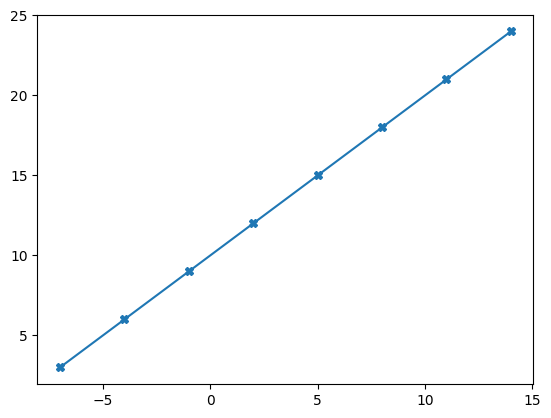

In [191]:
import numpy as np
import matplotlib.pyplot as plt

#features(independent variable)
x = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

#labels (dependent variable)
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

#plotting
plt.plot(x,y, "X-")
plt.show(block=True)

In [192]:
# relationship y = x + 10
assert np.all(y == x + 10)

##Input and Output Shapes

In [193]:
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [194]:
x = tf.constant(x)
y = tf.constant(y)

##modelling

* **Creating a model** - define th i/o layers, as well as the hidden layes of a deep learning model.
* **Compiling a model** - define the loss function (How wrong the model is) & optimizer (improve the learning) & evaluation metrics
* **fitting the model** - finding patterns


In [195]:
tf.random.set_seed(42)
#using sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#compiling
model.compile(loss=tf.keras.losses.mae, ## mae => np.mean(np.abs(y_true - y_pred))
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"]) #SGD => stochastic gradient descent
##removig layer => model.pop()
# model fitting

# Reshaping x to have an extra dimension
x_reshaped = tf.expand_dims(x, axis=-1)

model.fit(x_reshaped, y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step - loss: 12.6829 - mae: 12.6829
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 12.5504 - mae: 12.5504
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 12.4179 - mae: 12.4179
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 12.2854 - mae: 12.2854
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 12.1529 - mae: 12.1529


In [196]:
y_pred = model.predict(tf.constant([17, 0]))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


array([[6.993675],
       [0.05    ]], dtype=float32)

##Improving the model

Dense layer - fully connected

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="sigmoid"),
    tf.keras.layers.Dense(100, activation="sigmoid"),
    tf.keras.layers.Dense(1) # Changed to 1 unit to match the label shape
])

## tf.keras.optimizers.RMSprp(learning_rate=0.001, rho-0.9)
#=>step size
#=> discounting factor controling the influence of past gradent and the current gradient

model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["mae"]
)
model.fit(x_reshaped, y, epochs=5)

Epoch 1/5


In [ ]:
model.predict(tf.constant([12.0]))

In [ ]:
x = np.arange(-25, 25)
# Split data into train and test sets
x_train = x[:40] # first 40 examples (80% of data)
y_train = y[:40]

x_test = x[40:] # last 10 examples (20% of data)
y_test = y[40:]

len(x_train), len(x_test)

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(500, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001,
    ),
    metrics=["mae"]
)
model.fit(x_reshaped, y_train, epochs=100, verbose=0 )

In [ ]:
model.predict(tf.constant([11.0]))
model.summary()

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(500, activation="relu"),
    tf.keras.layers.Dense(200, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)
])
model.compile(
    loss=tf.losses.mae, ## / tf["mae"]
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), ## lr -(vital hyperparam)
    metrics=["mae"]
)
model.fit(x_reshaped, y_train, epochs=100, verbose=0)

In [ ]:
np.round(model.predict(np.array([17.0])), 4) ##
model.summary()


np.mean(np.abs(y_true - y_pred))

np.mean(np.abs(y_true - y_pred))

y_true = 17.0 + 10.0

y_pred = 27.5409


```
np.mean(np.abs(y_true - y_pred))
```
**Tweaking**
* hidden layers

* neurons

* activation fn

* opt fn

* adding layers

* learning_rate

* fitting for longer

* fitting more Data


## Eval Model => v, v, v
***assess the performance of trained model***

In [ ]:
#dataset

x = tf.cast(tf.range(-25, 25), dtype=tf.float32)
x

In [ ]:
y = x + 10
y

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x, y)


In [ ]:

# # => spliting
# from sklearn.model_selection import train_test_split

# x_train, x_test, y_train, y_test = train_test_split(x.numpy(), y.numpy(), test_size=0.2, random_state=42)

# len(x_train)
# x_train
# len(x_train), len(x_test), len(y_train), len(y_test)


In [ ]:
 ## for aligned - manual
len(x)

x_train = x[:40]
x_test = x[40:]

y_train = y[:40]
y_test = y[40:]
len(x_train), len(x_test), len(y_train), len(y_test)

## visualizing the data


In [ ]:
plt.figure(figsize=(7, 5))
# training
plt.scatter(x_train, y_train, c="b", label="training")
#test
plt.scatter(x_test, y_test, c="g", label="testing")

plt.legend()

## Creating neural network

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu", name="input_layer1"),
    tf.keras.layers.Dense(100, input_shape=[1], name='input_layer'), ##Dense => fully connected
    tf.keras.layers.Dense(1, name="output_layer") # Changed to 1 unit to match the label shape
], name="model2")
model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["mae"],
)#compiling
x_reshaped = tf.expand_dims(x_train, axis=-1)
model.fit(x_reshaped, y_train, epochs=100, verbose=0) # verbose - silent

In [ ]:
model.summary()
#params = input_dim * units + b

Trainable - params that can be model can update as it trains

In [ ]:
model.fit(x_reshaped, y_train, epochs=100, verbose=0)

In [ ]:
model.summary()
## layer1 = 100 * 1 + 100 = 200
## layer2 = 100 * 100 + 100 = 10100
## output_layer = 100 * 1 + 1 = 101
## total params = 200 + 200 + 101 = 10403 -> trainable + optimizers params

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model=model, show_shapes=True, show_trainable=False)

# V model

**plotting againist truth**

In [ ]:
y_pred = model.predict(x_test)
y_pred


In [ ]:
y_test ## expected output

In [ ]:
def plt_pred(train_data=x_train,
             train_labels=y_train,
             test_data=x_test,
             test_labels=y_test,
             predictions=y_pred):
  plt.figure(figsize=(10, 7))
  #plt training
  plt.scatter(train_data, train_labels, c="b", label="Training data")
  plt.scatter(test_data, test_labels, c="g", label="Testing data")
  # plot models pred
  plt.scatter(test_data, predictions, c="r", label="predictions")
  plt.legend()

In [ ]:
plt_pred()

### Evaluating model's predictions with regression

**Metrics**

*Main*

* MAE - mean absolute error
  

```
 tf.keras.losses.MAE()
 # or
 tf.keras.mean_absolute_error()
```



* **MSE** - mean squared error
  * larger errors are more significant than smaller errors.

```
 tf.keras.losses.MSE()
 #or
 tf.keras.MeanSquaredError()
```

* **Huber** - combo of MSE & MAE
```
tf.keras.losses.Huber()
```

In [ ]:
#on test
mse = tf.keras.losses.MeanSquaredError()(y_test, y_pred)
mae = tf.keras.losses.MeanAbsoluteError()(y_test, y_pred)
print(f"Model MSE on test set: {mse.numpy()}")
f"mse:{mse.numpy()}, mae: {mae.numpy()}"

In [ ]:
# reusable MAE & MSE

def mae(y_true, y_pred):
  return tf.metrics.MeanAbsoluteError()(y_true=y_true,
                                        y_pred=tf.squeeze(y_pred))
def mse(y_true, y_pred):
  return tf.metrics.MeanSquaredError()(y_true=y_true,
                                      y_pred=tf.squeeze(y_pred))

##Running experiment to improve the model

1. large datasets
2. make model larger
3. Train for longer

In [ ]:
x_train.numpy(), y_train.numpy()

In [ ]:
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(500, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1)
])
model_1.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["accuracy"]
)
model_1.fit(x_reshaped, y_train, epochs=100, verbose=0)

In [ ]:
#plt pred of model_1

y_pred_1 = model_1.predict(x_test)
plt_pred(predictions=y_pred_1)

In [ ]:
mae_1 = mae(y_test, y_pred_1)
mse_1 = mse(y_test, y_pred_1)
mae_1.numpy(), mse_1.numpy()

## Model_2

In [ ]:
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)
])
model_2.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["mse"]
)
model_2.fit(x_reshaped, y_train, epochs=100, verbose=0)

In [ ]:
y_preds_2 = model_2.predict(x_test)
y_preds_2

In [ ]:
plt_pred()

In [ ]:
model_2.summary()

In [ ]:
##eval metrics
mae_2 = mae(y_test, y_preds_2)
mse_2 = mse(y_test, y_preds_2)
mae_2, mse_2

**Model 3**

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)
])
model.compile(loss=["mae"],
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["accuracy"])
model.fit(x_reshaped, y_train, epochs=500, verbose=0)

In [ ]:
model.predict(x_test)

In [ ]:
y_pred_3 = model.predict(x_test)
plt_pred(predictions=y_pred_3)

**model 3 metrics**

In [ ]:
mae_3 = mae(y_test, y_pred_3)
mse_3 = mse(y_test, y_pred_3)
mae_3, mse_3

## Comparing the results

In [ ]:
import pandas as pd

results = [
    ["model_1", mae_1.numpy(), mse_1.numpy()],
    ["model_2", mae_2.numpy(), mse_2.numpy()],
    ["model_3", mae_3.numpy(), mse_3.numpy()]
]
all_results = pd.DataFrame(results, columns=["model", "mae", "mse"])
all_results

## tracking Experiments

**TensorBoard**
**weights & biases**

##Saving Model
**To use outside the environment**
* savedModel format
* HDF5 format

In [ ]:
#SavedModel format

model.save("saveModel_format.keras")

In [ ]:
# HDF5 format

model.save("hdf5_format.h5")

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

## loading saved models
load_savedModel_format = tf.keras.models.load_model("/content/saveModel_format.keras")
load_savedModel_format.summary()

In [ ]:
model.predict(x_test)

In [ ]:
##h5

loaded_h5_format = tf.keras.models.load_model('/content/hdf5_format.h5', custom_objects={'mae': mae, 'mse': mse})
loaded_h5_format.summary()

In [ ]:
# Testing if the models are the same
model.predict(x_test) == loaded_h5_format.predict(x_test)

##Downloading filess

In [ ]:
from google.colab import files

files.download('/content/hdf5_format.h5')

#**A Larger Model**


In [ ]:
####
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# ins dataset

insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
insurance

In [ ]:
insurance_one_hot = pd.get_dummies(insurance)
insurance_one_hot.head()

In [ ]:
x = insurance_one_hot.drop("charges", axis=1)
y = insurance_one_hot["charges"]

x.head()

In [ ]:
## y
y.head()

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

len(x_train), len(x_test)

In [ ]:
model.summary()

In [ ]:
##creating sequential model

insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1)
])

insurance_model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["mae"]
)

insurance_model.fit(x_train, y_train, epochs=100, verbose=0)

In [ ]:
insurance_model.evaluate(x_test, y_test)

In [ ]:
##median & mean
y_train.median(), y_train.mean()

## Improving model
* hidde layers extra neurons
* train for longer
* optmizer

In [ ]:
tf.random.set_seed(42)

insurance_model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)
])

insurance_model_1.compile(
    loss=["mae"],
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["mae"]
)

early_stoping = tf.keras.callbacks.EarlyStopping(
    monitor="loss",
    patience=5,
    restore_best_weights=True
)

history = insurance_model_1.fit(x_train, y_train,
                                epochs=100,
                                callbacks=[early_stoping],
                                verbose=0)
history

In [ ]:
insurance_model_1.evaluate(x_test, y_test)

In [ ]:
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")
plt.legend()

**EarlyStopping** - stop training when a monitored metrics stops improving. on insurance_model_1
 * avoid overfitting
 * wasting resources

## Preprocessing Data (Normalization and Standardization)

- Normalization -> change the values of numeric columns in the dataset to a common scale, maintaining their ranges.


**categorical && numerical data**

In [ ]:
x

In [ ]:
x["age"].plot(kind="hist", title="age", ylabel="age")
plt.show()

In [ ]:
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
insurance


In [ ]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

#column transformer
ct = make_column_transformer(
    ## when data do not follow a  normal distribution for SVM, k-nearest & decision trees
    (MinMaxScaler(), ["age", "bmi", "children"]), #turn all values in these columns btwn 0 and 1
    (OneHotEncoder(handle_unknown="ignore"), ["sex", "smoker", "region"])
)

##
x = insurance.drop("charges", axis=1)
y = insurance["charges"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## fit column transformer to training data
ct_fit = ct.fit(x_train)

## transforming training and testing Data
x_train_normal = ct.transform(x_train)
x_test_normal = ct.transform(x_test)


In [ ]:
x_train_normal[0]

In [260]:
x_train.loc[0]

,0
age,19
sex,female
bmi,27.9
children,0
smoker,yes
region,southwest


In [264]:
insurance_model_1.summary()

Model: "sequential_47"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_130 (Dense)               │ (None, 100)            │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_131 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_132 (Dense)               │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,205 (133.62 KB)

 Trainable params: 11,401 (44.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,804 (89.08 KB)

In [268]:
insurance_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])
insurance_model_2.compile(
    loss=["mae"],
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=["mae"]
)
insurance_model_2.fit(x_train_normal, y_train, epochs=100, verbose=2)

Epoch 1/100
34/34 - 2s - 52ms/step - loss: 13344.2148 - mae: 13344.2148
Epoch 2/100
34/34 - 0s - 10ms/step - loss: 13336.4102 - mae: 13336.4102
Epoch 3/100
34/34 - 0s - 8ms/step - loss: 13317.2793 - mae: 13317.2793
Epoch 4/100
34/34 - 0s - 6ms/step - loss: 13276.6699 - mae: 13276.6699
Epoch 5/100
34/34 - 0s - 6ms/step - loss: 13203.5049 - mae: 13203.5049
Epoch 6/100
34/34 - 0s - 7ms/step - loss: 13085.9199 - mae: 13085.9199
Epoch 7/100
34/34 - 0s - 4ms/step - loss: 12912.5234 - mae: 12912.5234
Epoch 8/100
34/34 - 0s - 3ms/step - loss: 12672.9248 - mae: 12672.9248
Epoch 9/100
34/34 - 0s - 3ms/step - loss: 12357.3828 - mae: 12357.3828
Epoch 10/100
34/34 - 0s - 4ms/step - loss: 11959.5908 - mae: 11959.5908
Epoch 11/100
34/34 - 0s - 4ms/step - loss: 11487.2803 - mae: 11487.2803
Epoch 12/100
34/34 - 0s - 3ms/step - loss: 10980.0762 - mae: 10980.0762
Epoch 13/100
34/34 - 0s - 4ms/step - loss: 10478.4121 - mae: 10478.4121
Epoch 14/100
34/34 - 0s - 3ms/step - loss: 9982.1621 - mae: 9982.1621
E

In [269]:
insurance_model_2.evaluate(x_test_normal, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 3517.3096 - mae: 3517.3096


[3431.1953125, 3431.1953125]